In [ ]:
# Trajectory sampler
# ================================
# This section performs sampling of the original descriptors matrix or reduced ones from dim_red.ipynb to generate an initial dataset


## Package importation

In [2]:
import os, glob, json
import numpy as np
import pandas as pd
from sampler_utils import sample, atoms_to_structures, load_reduced, pc_coverage_bins, pc_coverage_bins_auto
from dim_red_utils import load_pca_model
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.style as mplstyle
from plots_exports_utils import plot_sampling_pca, export_selected_structures, export_methods_bundle
# implementation from maml from reference: https://doi.org/10.1038/s41524-024-01227-4

from maml.sampling.direct import BirchClustering, DIRECTSampler, SelectKFromClusters


matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)
#matplotlib.use('Agg')  # Définir le backend en mode headless
mplstyle.use('fast') #The fast style set simplification and chunking parameters to reasonable settings to speed up plotting large amounts of data

## Data importation

In [3]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True 
if embedded_file:
    # Look for .npy file in embedding/ directory
    npy_files = glob.glob("embedding/*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/ directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")

    X = load_reduced(npy_file)  # or use np.load directly
    print("Loaded embedding with shape:", X.shape)

    pca_model_file = glob.glob("embedding/*.json") 
    if not pca_model_file:
        raise FileNotFoundError("No PCA model .json file found in embedding/ directory")
    if len(pca_model_file) > 1:
        raise RuntimeError(f"Multiple PCA model files found: {pca_model_file}")
    pca_model_file = pca_model_file[0]
    print(f"Using PCA model: {pca_model_file}")
    pca_model = load_pca_model(pca_model_file)
    
else: 
    # Look for .npy file in current directory
    npy_files = glob.glob("./*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")

# Find provenance parquet file
parquet_files = glob.glob("desc/*.parquet")
if not parquet_files:
    raise FileNotFoundError("No provenance .parquet file found in current directory")
if len(parquet_files) > 1:
    raise RuntimeError(f"Multiple parquet files found: {parquet_files}")
parquet_file = parquet_files[0]
print(f"Using provenance file: {parquet_file}")
meta = pd.read_parquet(parquet_file)

# Match corresponding JSON file with same timestamp
json_file = glob.glob("desc/*.json")
if not json_file:
    raise FileNotFoundError(f"No filemap JSON found")
if len(json_file) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_file}")
json_file = json_file[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

# specify the directory where sampling results are saved
path_to_results = "./selected" # Change if you want to save results elsewhere
os.makedirs(path_to_results, exist_ok=True)

#Check for NaNs

print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

# 1) whiten (float64 for stability)
X = np.asarray(X, dtype=np.float64, order="C")
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-12
Xw = (X - mu) / sd

print("Xw dtype/shape:", Xw.dtype, Xw.shape)
print("has_nan:", np.isnan(Xw).any(), "has_inf:", np.isinf(Xw).any(),
      "abs max:", np.nanmax(np.abs(Xw)))

Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (72720508, 4)
Using PCA model: embedding/pca_model.json
Using provenance file: desc/SOAP_N-O-C_provenance_20250925-115459.parquet
Using filemap: desc/SOAP_N-O-C_filemap_20250925-115459.json
X dtype/shape: float64 (72720508, 4)
has_nan: False has_inf: False abs max: 39.04179389712457
Xw dtype/shape: float64 (72720508, 4)
has_nan: False has_inf: False abs max: 18.216126522642124


## FPS sampling

In [ ]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="fps"
idx_atoms = sample(X, method=method, k=50000, seed=0, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")#choose="top", top_k=200)

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx_atoms, method="fps", per_pc=per_pc, npy_file=npy_file)

# One method

# Load sampled structures from CSV (not .npy)
save_files_fps = True
if save_files_fps:
    paths = export_selected_structures(chosen_structs, method_name="FPS", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto")
    print(paths)

Using Farthest-Point Sampling (FPS) ...


FPS:   0%|          | 1/49999 [00:06<88:39:23,  6.38s/it]


KeyboardInterrupt: 

## Random sampling

Using random sampling ...
Selected 48409 unique structures.
Mean coverage: 0.6113965150611926
Per-PC bins used: [346, 475, 480, 251]
Per-PC coverage: [0.6201780415430267, 0.6181434599156118, 0.4702127659574468, 0.7370517928286853]


Assembling: 100%|██████████| 48409/48409 [00:00<00:00, 73577.51it/s]


{'traj': './selected/Random_selected.traj', 'xyz': './selected/Random_selected.xyz'}


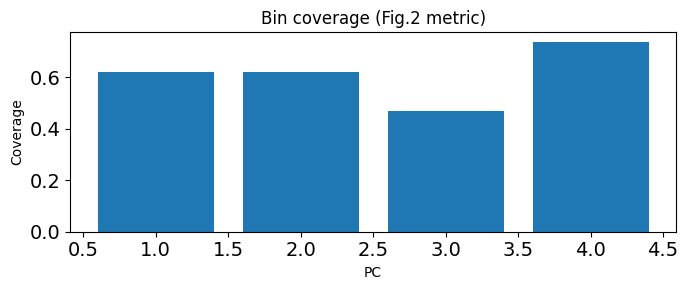

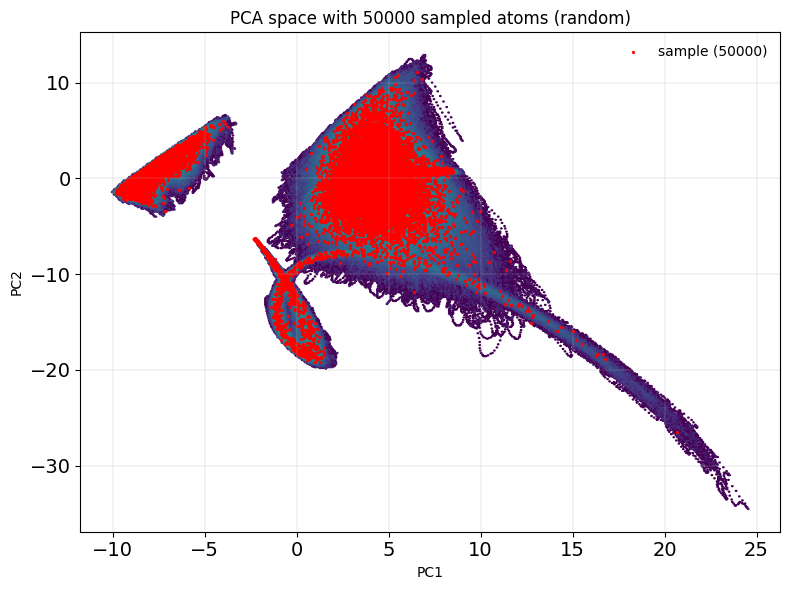

In [4]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="random"
idx_atoms = sample(X, method=method, seed=42, k=50000, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all") #choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx_atoms, method="random", per_pc=per_pc, npy_file=npy_file)

# One method
# export files — AUTO picks grouped if any file has >1 frame
save_files_rdn = True
if save_files_rdn:
    paths = export_selected_structures(
        chosen_structs,
        method_name="Random",
        outdir=path_to_results,
        extra_formats=("xyz",),         # add "xdatcar" if needed
        manifest=True,
        write_traj=True,
        load_mode="auto"                # or "grouped" to force one-shot reads
    )
    print(paths)

## BIRCH - my implementation

In [ ]:
my_implementation_of_birch = False
if my_implementation_of_birch:

    # inputs: PCA embedding Z (all rows), explained_variance EV (from your saved JSON)
    from sampler_utils import direct_birch_sample, pc_bin_coverage

    idx, info = direct_birch_sample(
        #Z_pca=first_two_PC, ev=ev_two_PC,
        Z_pca=X[:1000000], ev=pca_model.explained_variance_,
        n_clusters=100,          # or None → CF subclusters
        threshold=0.15,
        branching_factor=50,
        k_per_cluster=10,
        progress=True
    )
    print(info)

    # lift to structures with your existing atoms_to_structures(...)
    chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

    # save
    method="birch"
    np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
    chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
    )
    print("Mean coverage:", mean_cov)
    print("Per-PC bins used:", bins_used[:8])
    print("Per-PC coverage:", per_pc)

    plot_sampling_pca(X, idx, method="birch", per_pc=per_pc, npy_file=npy_file)

    # One method
    save_files_birch = False
    if save_files_birch:
        paths = export_selected_structures(chosen_structs, method_name="Birch", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
        #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
        print(paths)

Using DIRECT-style BIRCH sampling ...
from reference: https://doi.org/10.1038/s41524-024-01227-4


: 

In [5]:
DIRECT_sampler = DIRECTSampler(
    structure_encoder=None,
    pca=None,
    scaler=None,
    weighting_PCs=True,
    clustering=BirchClustering(n=10000, threshold_init=0.15), select_k_from_clusters=SelectKFromClusters(k=5)
)

DIRECT_selection = DIRECT_sampler.fit_transform(X)

idx = DIRECT_selection["selected_indexes"]

chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

# save
method="birch"
#np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
#chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx, method="birch", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_birch = False
if save_files_birch:
    paths = export_selected_structures(chosen_structs, method_name="Birch", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)

: 

## KPP 

In [ ]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="kpp"
idx = sample(X, method="kpp", k=15000, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all") #choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx, method="kpp", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_kpp = False
if save_files_kpp:
    paths = export_selected_structures(chosen_structs, method_name="KPP", outdir=path_to_results, extra_formats=("xyz"), load_mode="auto" )
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)